# Linear regression

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Understand the difference between regression and classification;
- Understand the analytical solution to least-squares regression;
- Understand the mathematical conditions underlying linear regression;
- Understand the impact of outliers on the linear regression solution.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.

**Note:**
In providing your answers to the questions, please denote which question you are providing an answer to (either in text or code) by commenting it with something like "Exercise 1.1" and "Exercise 3.4". This improves readability of your solutions as well as the quality of the feedback you will get.


## Top-down view onto this notebook
This assignment uses a toy dataset to familiarize you with linear regression using the analytical solution. Specifically;
1. In exercise 1, you will perform linear regression yourself, visualize the errors, and compare with NumPy's implementation;
2. In exercise 2, you will dive deeper into the mathematics behind linear regression;
3. In exercise 3, you will analyse the effect of outliers on linear regression.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Exercise 1: Least squares regression

We want to implement a least-square linear regression. This means that given a set of points $\{\mathbf{x_i},y_i\}$, $i = 1..N$, we want to find the line (or hyperplane in higher dimensions) which minimizes the least-square error. The least-square error measures the quadratic distance from the predicted points by the linear model to the actual values.

The general formula of the least square regression is $\mathbf{y} = \mathbf X \boldsymbol w+ \mathbf{\epsilon}$ where $\epsilon$ is a vector with dimensionality $\mathbb{R}^N$ containing the normally-distributed noise terms $N(0,\sigma^2)$, $\mathbf{y}$ is the vector of labels and $\mathbf{X}$ is the matrix of data points with dimensionality $\mathbb{R}^{N\times D}$. We are interested in finding a good estimate $\hat{\boldsymbol w}$ of the true weight vector $\boldsymbol w$. The estimate is given by:

\begin{equation}
\hat{\boldsymbol w} = (\mathbf{X}^{\rm T}\mathbf{X})^{-1} \mathbf{X}^{\rm T}\mathbf{y}
\end{equation}

where $\mathbf{X}$ is the matrix of regressor data (the first column is all 1’s for the intercept), and $\mathbf{y}$ is the vector of the dependent variable data. 

1. Explain in a few lines what the difference is between regression and classification.
1. Look at how the following data is generated. What are the real parameters of w?
1. We want to implement a least-squares linear regression now. Follow the following steps:
    1. Bring the data in the correct shape as requested by the formula above.    
    2. Calculate the estimates of the coefficients w.
    3. Add the resulting line to the given scatter plot of the data.
    4. Compute the mean square-error of the residuals, i.e. $ \frac{1}{N}\sum_{i=1}^N \|y(x_i) - y_i \|^2$.
    5. Compare your results to the numpy function `np.linalg.lstsq()`
1. Plot the residuals (e.g. using seaborn function `residplot()`

In [ ]:
# Generate data
N_samples = 100
white_noise_stddev = 2
X = np.random.randn(N_samples, 1)
eps = np.random.randn(N_samples, 1) * white_noise_stddev
w = [1.3]
y = 0.5 + w * X + eps

# Plot the data
plt.figure()
plt.scatter(X, y);
plt.grid()
plt.xlabel("x")
plt.ylabel("y")


In [ ]:
# Answer here

## Exercise 2: Mathematical concepts of linear regression

Let's look more closely at the mathematical backgrounds of the least-square linear regression. One step before obtaining the final solution $\hat{\boldsymbol w} = (\mathbf{X}^{\rm T}\mathbf{X})^{-1} \mathbf{X}^{\rm T}\mathbf{y}$, one has the so-called normal equations: 
\begin{equation}
(\mathbf{X}^{\rm T}\mathbf{X}) \hat{\boldsymbol w} = \mathbf{X}^{\rm T}\mathbf{y}
\end{equation}

In case $(\mathbf{X}^{\rm T}\mathbf{X})$ is not invertible, one applies a so-called Moore-Penrose pseudoinverse. This is a generalization of the common matrix inversion to singular or non-quadratic matrices. 

1. Which condition on X has to be satisifed such that $(\mathbf{X}^{\rm T}\mathbf{X})$ can be inverted?
2. Name scenarios in which this condition is violated.
3. Read about the pseudoinverse and list three properties of the pseudoinverse.


Answer here

## Exercise 3: The role of outliers in least-square linear regression

Sometimes the data is not as clean as in the above case. In the following data set, we added one additional point [45, 12] to the previous data set. We want to investigate how this point influences the estimates of $\mathbf w$ and find a strategy to avoid any occurring problems.

1. Apply a least square linear estimator to the new data set and visualize the results.
2. Compare the estimator for w with the one from before.
3. Plot the residuals.
4. There are several conditions on the residual which should be satisfied for the linear regression. Check them in this case.
5. What do you conclude from this example regarding the estimated weight vector and residuals? 
6. Think of possible strategies to avoid this problem.
7. (Optional) Implement a method to detect and remove the outlier.

In [ ]:
# Generate data
N_samples = 100
white_noise_stddev = 2
X = np.random.randn(N_samples, 1)
eps = np.random.randn(N_samples, 1) * white_noise_stddev
w = [1.3]
y = 0.5 + w * X + eps

# Add outlier
X = np.append(X, [[45]], axis=0)
y = np.append(y, [[12]], axis=0)

# Plot the data
plt.figure()
plt.scatter(X, y);
plt.grid()
plt.xlabel("x")
plt.ylabel("y")


In [ ]:
# Answer here

## (Optional) Exercise 4: Basis functions

What if our data does not follow a nice straight line? As discussed in the lecture, linear regression can learn non-linear functions when using non-linear basis functions. Basis functions $\phi(x)$ are a simple (non-linear) preprocessing of your features. If we can make an educated guess about the function underlying the data, we can use non-linear basis functions to learn the parameters of these non-linear functions with linear regression.

(Note, the solutions to this optional exercise are extremely short, you do not need more than a few lines of code per sub-exercise.)

1. Inspect the code and plot below. Is the data in this plot linear?
1. Can you think of a basis function $\phi(x)$ that would yield a similarly shaped function when applied to ```x```? Implement your basis function ```phi(x)```.
1. Apply your basis function on the data ```x``` and estimate parameters ```w``` using the analytical solution (see code below where this is done without applying a basis function first). Do these found parameters ```w``` make sense given function ```f(x)```?
1. Using the function provided below, plot the data and your learned model.
1. Compute the MSE between the model that you found (i.e., $\mathbf{w}^T\phi(\mathbf{x})$) and the targets ```y```. Is this MSE better than the MSE obtained when using a simple straight line model?


MSE is: 11.37


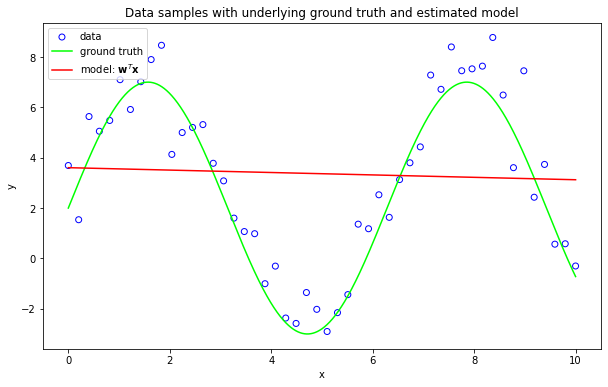

In [2]:
# Funky colours
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)


def f(x):
    return 2 + 5 * np.sin(x) # some non-linear function

def w_estimate(X, y):
     return np.linalg.inv(X.T @ X) @ X.T @ y
     
def plot_data_and_model(x,y, w, phi=None, use_basis_function=False):
    fig = plt.figure(figsize=(10,6))
    plt.scatter(x, y, facecolors='none', edgecolors='b', label="data")
    x_cont = np.linspace(start=x[0], stop=x[-1], num=x.shape[0]*100)
    y_cont = f(x_cont)
    plt.plot(x_cont,y_cont, color=colors["lime"], label='ground truth')
    plt.title("Data samples with underlying ground truth and estimated model")    
    if use_basis_function:
        plt.plot(x,w[0]+w[1]*phi(x), c='red', label=r'model: $\mathbf{w}^T\phi(\mathbf{x})$')
    else:
        plt.plot([0, 10], np.dot([[1, 0], [1, 10]], w), c='red', label=r'model: $\mathbf{w}^T\mathbf{x}$') 
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

N = 50
x = np.linspace(start=0, stop=10, num=N)
y = f(x) + np.random.normal(loc=0,scale=1,size=(x.shape[0])) # labels with some added Gaussian noise.

X = np.column_stack((np.ones(x.shape[0]), x))  # add bias (augmented notation)
w_est = w_estimate(X,y) # Estimate parameters of linear fit
res_error = (w_est@X.T - y)**2  # Compute squared residual errors
print("MSE is: {:.2f}".format(np.mean(res_error)))

plot_data_and_model(x=x,y=y,w=w_est)

## (Optional) Exercise 5: Polynomial regression

As we have seen in the previous exercise, data does not always follow a nice straight line. But coming up with suitable basis functions can be challenging, time consuming and may even require guesswork. Is there another way to learn linear models that fit non-linear functions that require less guessing work? Yes, polynomial regression.

In plain linear regression we learn weights such that we fit a linear function: $f(\mathbf{x},\mathbf{w}) = \mathbf{w}^T\mathbf{x}$ (note the augmented notation). In the above exercise we used a non-linear basis function to **replace** our feature(s) in order to learn a linear model that can fit non-linear functions: $f(\mathbf{x},\mathbf{w})=\mathbf{w}^T\phi(\mathbf{x})$. 

Here, we abuse the fact that you can approximate any continuous function (defined on a closed interval) by a polynomial function. Furthermore, we could also **add** features instead of **replacing** our features with the preprocessed features. In polynomial regression, we learn a polynomial function (the clue is in the name). This means we learn a function of the shape $f(x,\mathbf{w}) = w_0 + w_1x + w_2x^2 + ... + w_Mx^M = \sum_{j=0}^M w_jx^j$, where $M$ is the order of the polynomial. We can view it as using $M+1$ basis functions: $\phi_j(x) = x^j$ to write $f(x,\mathbf{w}) = \mathbf{w}^T\boldsymbol{\phi}(x)$. If we apply these basis functions $\boldsymbol{\phi}$ to our data, we obtain our preprocessed data $\Phi$. This matrix $\Phi$ is known in the literature as a *design matrix*. What is cool is that we can simply use this design matrix $\Phi$ instead of our data matrix $X$ in the analytical solution (equation 1 at the beginning of this notebook) to estimate the parameters of the model that minimse the MSE! 

(Note again, the answers to these questions should be very short (for the first 5, it's 1 or 2 lines pre sub-exercise))
1. Inspect the code below, how do $\phi_j(x)$ and $\Phi$ relate to each other?
1. Get the design matrix $\Phi_\text{train}$ of the training data ```X_train``` (note, only of the first feature as the bias will be added in the ```get_Phi()``` function). You can choose an order $M$ in range [0,9] that you think is reasonable.
1. Use the provided function ```w_estimate()``` with your design matrix $\Phi_\text{train}$ to learn the parameters of your polynomial.
1. Print the obtained MSE.
1. Plot (using the provided updated function ```plot_data_and_model()```) the data and your model in a single plot. Note, the function expects the data matrix $X$ (augmented notation), this is for plotting purposes. In the function we use many more values of x to create smoother plots. If you plot a line for the model's predictions at the observations, you would plot a line interpolating between the predictions of our model at only the observed samples. We would not plot the actual learned function of the model. 
1. What happens if you take a relatively small order $M$ and what happens if you take a relatively large order $M$ (i.e., 9)? Try for different orders M over the range [0, 9]
1. How could we find a suitable order $M$ for our polynomial, given that $M$ is a hyperparameter? 
1. Polynomial regression is no magical solution to all problems. What happens if you predict the label of a test sample that was outside of the range of your training data? Plot ```X```, ```y``` and the model parameters learned from ```X_train``` in a single figure using the provided function. Report on the MSE obtained by the weights trained on ```X_train``` when applied on all of ```X```. Does polynomial regression genalise well beyond the range of the training data?

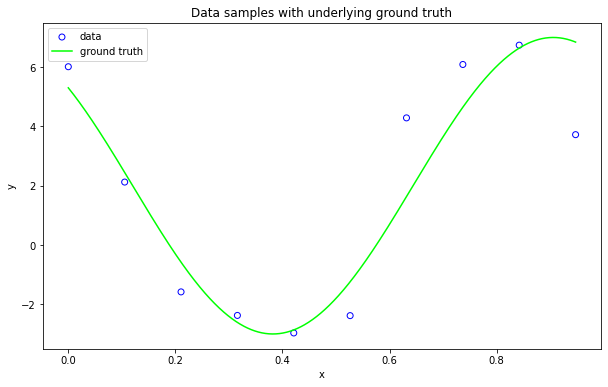

In [3]:
# New, funkier, data:
np.random.seed(2023)

def f(x):
    return 2 + 5*np.cos(6*(x-3))  # some non-linear function 

def phi(j,x):
    return x**j

def get_Phi(x,M): # NOTE, this function expects your raw data x (not augmented notation)
    Phi = np.zeros(shape=(x.shape[0],M+1))
    for j in range(M+1):
        Phi[:,j] = phi(j,x)
    return Phi

def plot_data_and_model(X,y, w, M=2, plot_model=True):
    fig = plt.figure(figsize=(10,6))
    x = X[:,1]
    plt.scatter(x, y, facecolors='none', edgecolors='b', label="data")
    x_cont = np.linspace(start=x[0], stop=x[-1], num=x.shape[0]*100)
    y_cont = f(x_cont)
    X = get_Phi(x_cont, M)
    plt.plot(x_cont,y_cont, color=colors["lime"], label='ground truth')
    if plot_model:
        plt.title(f"Data samples with underlying ground truth and estimated model of order M={M}")    
        plt.plot(x_cont,w@X.T, c='red', label=r'model: $\mathbf{w}^T\phi(\mathbf{x})$') 
    else:
        plt.title("Data samples with underlying ground truth")    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show() 
    
    
# Generating data
N_samples = 20
x = np.linspace(start=0, stop=2, num=N_samples)
X = np.column_stack((np.ones(x.shape[0]), x)) # add bias (augmented notation)
y = f(x) + np.random.normal(loc=0,scale=1,size=(x.shape[0])) # non-linear function with some added Gaussian noise (sd = 1).        

# Train/test
X_train = X[:int(N_samples/2)]
X_test = X[int(N_samples/2):]
y_train = y[:int(N_samples/2)]
y_test = y[int(N_samples/2):]

# Plot training data
plot_data_and_model(X_train,y_train, w=None, plot_model=False)

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here